Files extracted successfully.
x_train shape: (4400, 28, 28, 1)
y_train shape: (4400,)
x_test shape: (1100, 28, 28, 1)
y_test shape: (1100,)


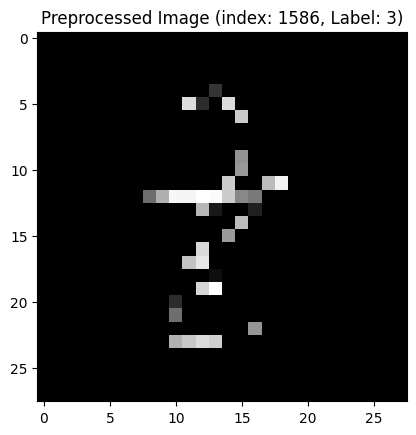

In [2]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# Image resizing dimensions
img_size = 28

def preprocess_image(img, target_size=20, final_size=img_size, tolerance=10, invert=True):
    # Find the bounding rectangle of the non-zero pixels with tolerance
    rows = np.any(img < 255 - tolerance, axis=1)  # Adjust tolerance as needed
    cols = np.any(img < 255 - tolerance, axis=0)

    if not np.any(rows) or not np.any(cols):  # Check if there are any non-white pixels
        return None

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Crop the image
    cropped_img = img[rmin:rmax, cmin:cmax]

    # Calculate the aspect ratio of the cropped image
    h, w = cropped_img.shape[:2]
    aspect_ratio = w / h

    # Resize while maintaining aspect ratio
    if aspect_ratio > 1:  # Wider than tall
        new_w = target_size
        new_h = int(target_size / aspect_ratio)
    else:  # Taller than wide or square
        new_h = target_size
        new_w = int(target_size * aspect_ratio)
    resized_img = cv2.resize(cropped_img, (new_w, new_h))

    # Create a final_size x final_size canvas and paste the resized image centered
    canvas = np.ones((final_size, final_size), dtype=np.uint8) * 255  # Initialize with white background
    x_offset = (final_size - new_w) // 2
    y_offset = (final_size - new_h) // 2
    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized_img

    # Increase contrast
    alpha = 1.5  # Contrast control (1.0-3.0)
    beta = 0  # Brightness control (0-100)
    canvas = cv2.convertScaleAbs(canvas, alpha=alpha, beta=beta)

    if invert:
        canvas = 255 - canvas

    return canvas


# Replace with the actual path to your digits.zip file
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/vowels.zip'

# Extract the zip file
extracted_folder_path = '/content/drive/MyDrive/extracted_vowels'
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_folder_path)
    print("Files extracted successfully.")
except Exception as e:
    print(f"Error extracting zip file: {e}")
    raise

# Initialize lists for images and labels
train_images, test_images = [], []
train_labels, test_labels = [], []

# Iterate through the extracted folders
for folder_name in os.listdir(extracted_folder_path):
    folder_path = os.path.join(extracted_folder_path, folder_name)
    if os.path.isdir(folder_path):
        try:
            label = int(folder_name)  # Assuming folder names are 0-10
        except ValueError:
            print(f"Skipping invalid folder name: {folder_name}")
            continue

        class_images = []
        for filename in os.listdir(folder_path):
            if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    processed_img = preprocess_image(img)
                    if processed_img is not None:
                        class_images.append(processed_img)

        # Split each class into train and test sets
        train_imgs, test_imgs = train_test_split(class_images, test_size=0.2, random_state=42)

        train_images.extend(train_imgs)
        test_images.extend(test_imgs)
        train_labels.extend([label] * len(train_imgs))
        test_labels.extend([label] * len(test_imgs))

train_images = np.array(train_images)
train_labels = np.array(train_labels)
test_images = np.array(test_images)
test_labels = np.array(test_labels)

# Reshape the images to (samples, height, width, channels)
train_images = train_images.reshape(-1, img_size, img_size, 1)
test_images = test_images.reshape(-1, img_size, img_size, 1)

# Normalize pixel values to the range [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

x_train, x_test, y_train, y_test = train_images, test_images, train_labels, test_labels

# Print shapes of the datasets
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# Display a random image from x_train
random_index = random.randint(0, len(x_train) - 1)
random_image = x_train[random_index].reshape(img_size, img_size)  # Reshape to 28x28
plt.imshow(random_image, cmap='gray')
plt.title(f"Preprocessed Image (index: {random_index}, Label: {y_train[random_index]})")
plt.show()


In [3]:
!pip install tensorflow

In [4]:
import tensorflow as tf
print(tf.__version__)

2.17.1


In [5]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [9]:
# Image resizing dimensions
img_size = 28  # You can adjust this if needed

def preprocess_image(img, target_size=20, final_size=img_size, tolerance=10, invert=True):
    # Find the bounding rectangle of the non-zero pixels with tolerance
    rows = np.any(img < 255 - tolerance, axis=1)
    cols = np.any(img < 255 - tolerance, axis=0)

    if not np.any(rows) or not np.any(cols):  # Check if there are any non-white pixels
        return None

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Crop the image
    cropped_img = img[rmin:rmax, cmin:cmax]

    # Calculate the aspect ratio of the cropped image
    h, w = cropped_img.shape[:2]
    aspect_ratio = w / h

    # Resize while maintaining aspect ratio
    if aspect_ratio > 1:  # Wider than tall
        new_w = target_size
        new_h = int(target_size / aspect_ratio)
    else:  # Taller than wide or square
        new_h = target_size
        new_w = int(target_size * aspect_ratio)
    resized_img = cv2.resize(cropped_img, (new_w, new_h))

    # Create a final_size x final_size canvas and paste the resized image centered
    canvas = np.ones((final_size, final_size), dtype=np.uint8) * 255  # Initialize with white background
    x_offset = (final_size - new_w) // 2
    y_offset = (final_size - new_h) // 2
    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized_img

    # Increase contrast
    alpha = 1.5  # Contrast control (1.0-3.0)
    beta = 0  # Brightness control (0-100)
    canvas = cv2.convertScaleAbs(canvas, alpha=alpha, beta=beta)

    if invert:
        canvas = 255 - canvas

    return canvas

# Load and preprocess dataset
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/vowels.zip'  # Adjust path as needed
extracted_folder_path = '/content/drive/MyDrive/extracted_vowels'  # Adjust path as needed

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_folder_path)

# Initialize lists for images and labels
train_images, test_images = [], []
train_labels, test_labels = [], []

# Iterate through the extracted folders
for folder_name in os.listdir(extracted_folder_path):
    folder_path = os.path.join(extracted_folder_path, folder_name)
    if os.path.isdir(folder_path):
        try:
            label = int(folder_name)  # Assuming folder names are 0-9
        except ValueError:
            print(f"Skipping invalid folder name: {folder_name}")
            continue

        class_images = []
        for filename in os.listdir(folder_path):
            if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    processed_img = preprocess_image(img)
                    if processed_img is not None:
                        class_images.append(processed_img)

        # Split each class into train and test sets
        train_imgs, test_imgs = train_test_split(class_images, test_size=0.2, random_state=42)

        train_images.extend(train_imgs)
        test_images.extend(test_imgs)
        train_labels.extend([label] * len(train_imgs))
        test_labels.extend([label] * len(test_imgs))

train_images = np.array(train_images)
train_labels = np.array(train_labels)
test_images = np.array(test_images)
test_labels = np.array(test_labels)

# Reshape the images to (samples, height, width, channels)
train_images = train_images.reshape(-1, img_size, img_size, 1)
test_images = test_images.reshape(-1, img_size, img_size, 1)

# Normalize pixel values to the range [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Print shapes of the datasets
print("x_train shape:", train_images.shape)
print("y_train shape:", train_labels.shape)
print("x_test shape:", test_images.shape)
print("y_test shape:", test_labels.shape)

x_train shape: (4400, 28, 28, 1)
y_train shape: (4400,)
x_test shape: (1100, 28, 28, 1)
y_test shape: (1100,)


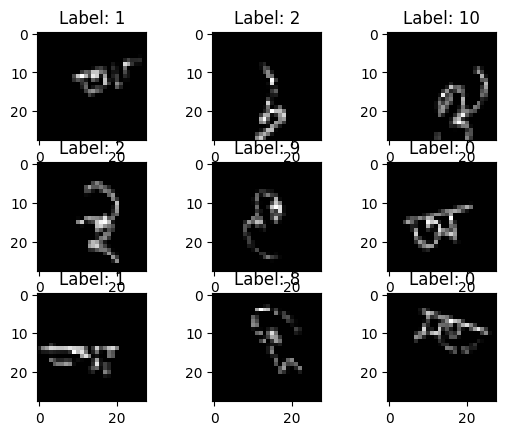

In [10]:
# Step 2: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fitting the data generator
datagen.fit(train_images)

# Example of augmented images (you can modify this code to visualize some of the augmentations)
for X_batch, y_batch in datagen.flow(train_images, train_labels, batch_size=9):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_batch[i].reshape(img_size, img_size), cmap='gray')
        plt.title(f"Label: {y_batch[i]}")
    plt.show()
    break  # Only show the first batch of augmented images


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build the CNN model
model = Sequential()

# Convolutional layers with ReLU activations
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output of the convolutional layers
model.add(Flatten())

# Fully connected layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))  # 10 classes (0 to 9)

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

Invalid label 10 in folder name: 10. Skipping this folder.
x_train shape: (4000, 28, 28, 1)
y_train shape: (4000,)
x_test shape: (1000, 28, 28, 1)
y_test shape: (1000,)


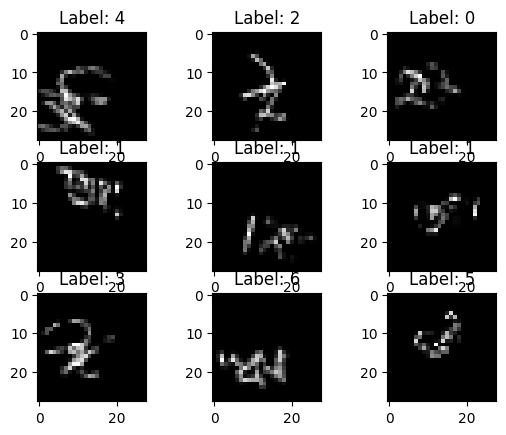

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.1710 - loss: 2.2312 - val_accuracy: 0.3250 - val_loss: 1.8126
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.2633 - loss: 1.9596 - val_accuracy: 0.3390 - val_loss: 1.6168
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.3324 - loss: 1.7495 - val_accuracy: 0.3870 - val_loss: 1.4865
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.3963 - loss: 1.6001 - val_accuracy: 0.4110 - val_loss: 1.3926
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.4234 - loss: 1.5250 - val_accuracy: 0.4330 - val_loss: 1.3076
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4425 - loss: 1.4358 - val_accuracy: 0.4600 - val_loss: 1.2950
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.4422 - loss: 1.4226 - val_accuracy: 0.4410 - val_loss: 1.3424
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.4594 - loss: 1.3905 - val_accuracy: 0.468

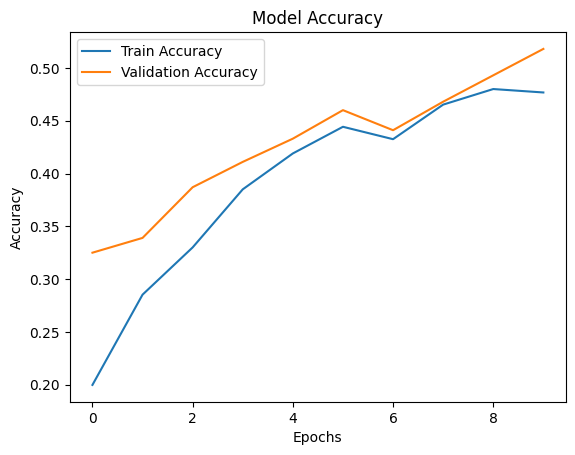

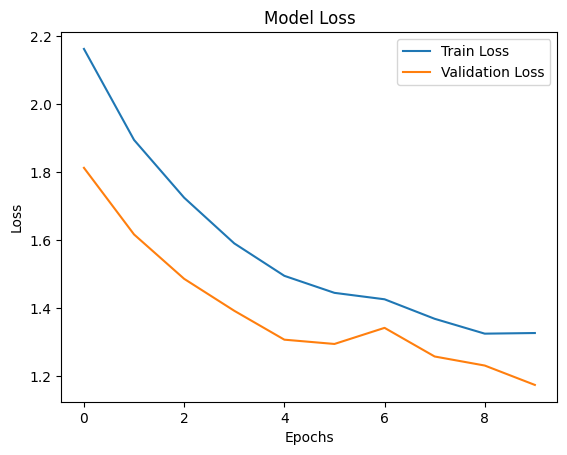

In [12]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Image resizing dimensions
img_size = 28  # You can adjust this if needed

def preprocess_image(img, target_size=20, final_size=img_size, tolerance=10, invert=True):
    # Find the bounding rectangle of the non-zero pixels with tolerance
    rows = np.any(img < 255 - tolerance, axis=1)
    cols = np.any(img < 255 - tolerance, axis=0)

    if not np.any(rows) or not np.any(cols):  # Check if there are any non-white pixels
        return None

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Crop the image
    cropped_img = img[rmin:rmax, cmin:cmax]

    # Calculate the aspect ratio of the cropped image
    h, w = cropped_img.shape[:2]
    aspect_ratio = w / h

    # Resize while maintaining aspect ratio
    if aspect_ratio > 1:  # Wider than tall
        new_w = target_size
        new_h = int(target_size / aspect_ratio)
    else:  # Taller than wide or square
        new_h = target_size
        new_w = int(target_size * aspect_ratio)
    resized_img = cv2.resize(cropped_img, (new_w, new_h))

    # Create a final_size x final_size canvas and paste the resized image centered
    canvas = np.ones((final_size, final_size), dtype=np.uint8) * 255  # Initialize with white background
    x_offset = (final_size - new_w) // 2
    y_offset = (final_size - new_h) // 2
    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized_img

    # Increase contrast
    alpha = 1.5  # Contrast control (1.0-3.0)
    beta = 0  # Brightness control (0-100)
    canvas = cv2.convertScaleAbs(canvas, alpha=alpha, beta=beta)

    if invert:
        canvas = 255 - canvas

    return canvas

# Load and preprocess dataset
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/vowels.zip'
extracted_folder_path = '/content/drive/MyDrive/extracted_vowels'

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_folder_path)

# Initialize lists for images and labels
train_images, test_images = [], []
train_labels, test_labels = [], []

# Iterate through the extracted folders
for folder_name in os.listdir(extracted_folder_path):
    folder_path = os.path.join(extracted_folder_path, folder_name)
    if os.path.isdir(folder_path):
        try:
            label = int(folder_name)
            if label < 0 or label > 9:
                print(f"Invalid label {label} in folder name: {folder_name}. Skipping this folder.")
                continue
        except ValueError:
            print(f"Skipping invalid folder name: {folder_name}")
            continue

        class_images = []
        for filename in os.listdir(folder_path):
            if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    processed_img = preprocess_image(img)
                    if processed_img is not None:
                        class_images.append(processed_img)

        # Split each class into train and test sets
        train_imgs, test_imgs = train_test_split(class_images, test_size=0.2, random_state=42)

        train_images.extend(train_imgs)
        test_images.extend(test_imgs)
        train_labels.extend([label] * len(train_imgs))
        test_labels.extend([label] * len(test_imgs))

train_images = np.array(train_images)
train_labels = np.array(train_labels)
test_images = np.array(test_images)
test_labels = np.array(test_labels)

# Reshape the images to (samples, height, width, channels)
train_images = train_images.reshape(-1, img_size, img_size, 1)
test_images = test_images.reshape(-1, img_size, img_size, 1)

# Normalize pixel values to the range [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Print shapes of the datasets
print("x_train shape:", train_images.shape)
print("y_train shape:", train_labels.shape)
print("x_test shape:", test_images.shape)
print("y_test shape:", test_labels.shape)

# Step 2: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fitting the data generator
datagen.fit(train_images)

# Example of augmented images (you can modify this code to visualize some of the augmentations)
for X_batch, y_batch in datagen.flow(train_images, train_labels, batch_size=9):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_batch[i].reshape(img_size, img_size), cmap='gray')
        plt.title(f"Label: {y_batch[i]}")
    plt.show()
    break  # Only show the first batch of augmented images

# Define a simple CNN model for classification
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 output classes (0-9)
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model using the augmented data
history = model.fit(datagen.flow(train_images, train_labels, batch_size=32),
                    epochs=10,
                    validation_data=(test_images, test_labels))

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [13]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4848 - loss: 1.1675
Test Accuracy: 51.80%
Test Loss: 1.1747
